<a href="https://colab.research.google.com/github/AadityaBhure/Deep-Learning-Lab---7th-Semester/blob/main/prac6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
#Aaditya Bhure 23070521034
#Importing Libraries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

In [7]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)
Training labels shape: (60000,)
Testing labels shape: (10000,)


In [8]:
# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)


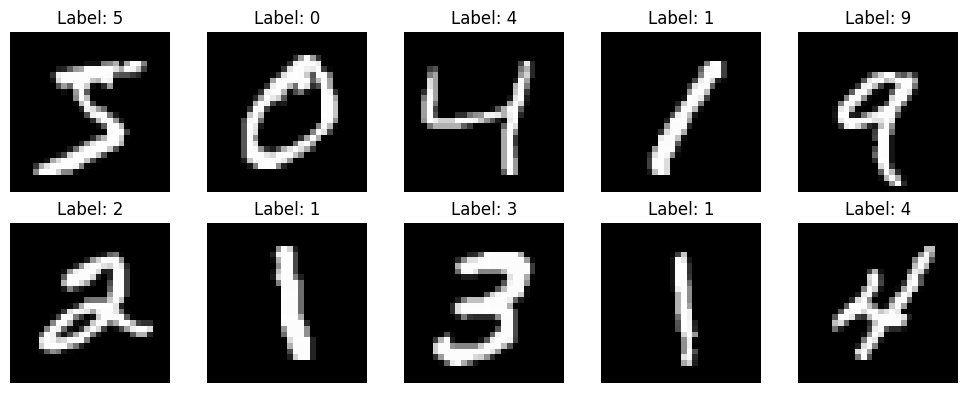

In [9]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
model = models.Sequential([

    # Convolution layer
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),

    # Pooling layer
    layers.MaxPooling2D((2, 2)),

    # Second convolution layer
    layers.Conv2D(64, (3, 3), activation="relu"),

    # Second pooling layer
    layers.MaxPooling2D((2, 2)),

    # Flatten feature maps
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Output layer - 10 digits
    layers.Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 100ms/step - accuracy: 0.9308 - loss: 0.2290 - val_accuracy: 0.9800 - val_loss: 0.0678
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 84s 106ms/step - accuracy: 0.9809 - loss: 0.0619 - val_accuracy: 0.9868 - val_loss: 0.0487
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 101ms/step - accuracy: 0.9871 - loss: 0.0420 - val_accuracy: 0.9867 - val_loss: 0.0419
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - accuracy: 0.9905 - loss: 0.0311 - val_accuracy: 0.9902 - val_loss: 0.0394
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 100ms/step - accuracy: 0.9923 - loss: 0.0241 - val_accuracy: 0.9903 - val_loss: 0.0331


In [13]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.030286913737654686
Test Accuracy: 0.9909999966621399


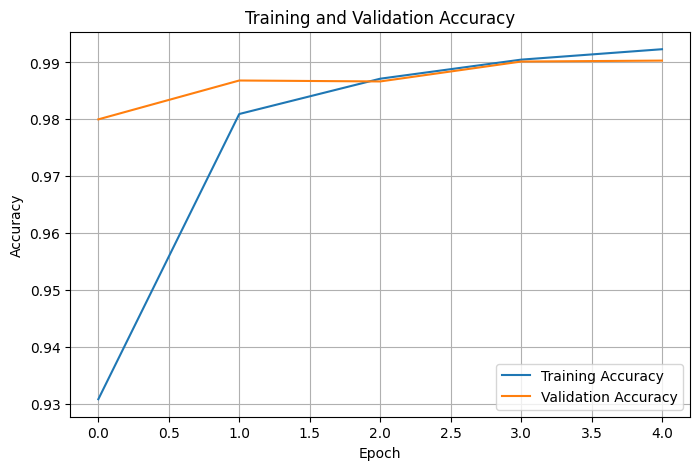

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

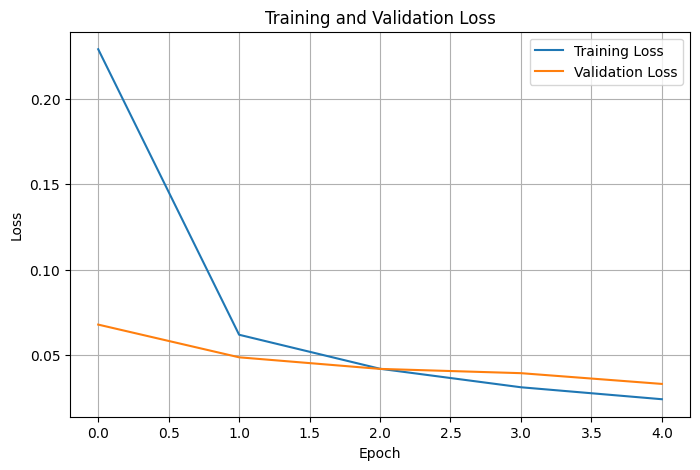

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [16]:
predictions = model.predict(x_test)

# Convert probabilities to predicted digit
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted labels:")
print(predicted_labels[:20])

print("\nActual labels:")
print(y_test[:20])

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Predicted labels:
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 8 4]

Actual labels:
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


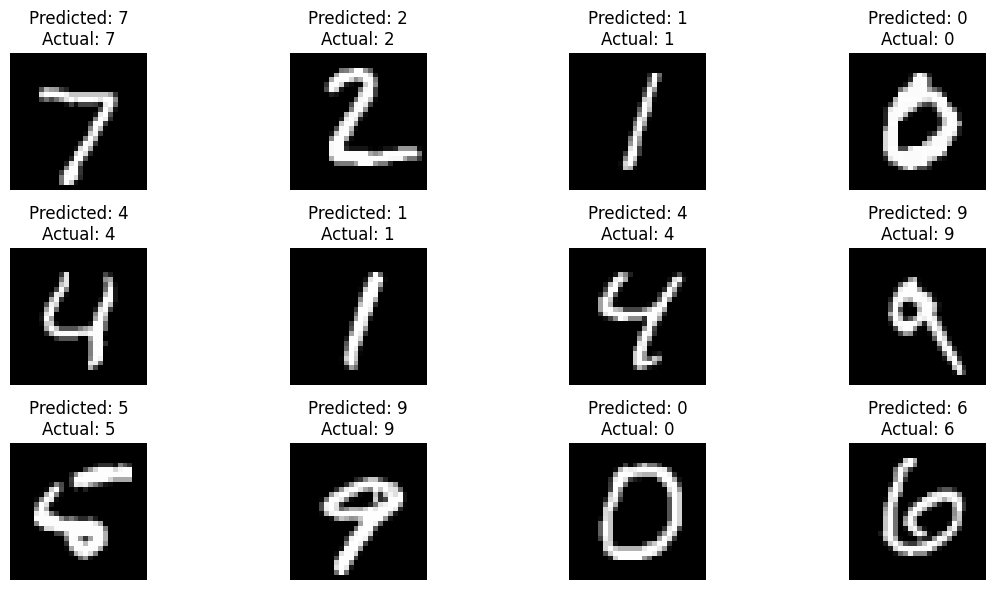

In [17]:
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[i].squeeze(), cmap="gray")

    predicted = predicted_labels[i]
    actual = y_test[i]

    plt.title(f"Predicted: {predicted}\nActual: {actual}")
    plt.axis("off")

plt.tight_layout()
plt.show()

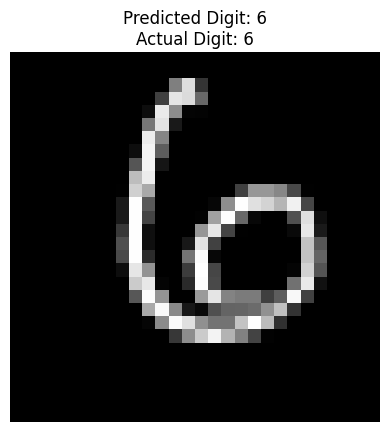

In [18]:
index = 100

plt.imshow(x_test[index].squeeze(), cmap="gray")
plt.axis("off")
plt.title(
    f"Predicted Digit: {predicted_labels[index]}\n"
    f"Actual Digit: {y_test[index]}"
)
plt.show()